# Task 2 — Coral Reef Bleaching Early Warning: DHW Hindcast
**Dataset:** Andaman & Nicobar Islands — MODIS Aqua + ERA5 reanalysis (2004–2024, weekly)  
**Goal:** Train a 4-week ahead Degree Heating Weeks (DHW) forecast model on pre-event data (2004–2009), then hindcast the 2010 Indian Ocean Dipole bleaching event to test whether the model could have issued advance warning.


In [1]:
# ── Cell 1 ── Imports & paths ─────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

ROOT   = Path('..')
RAW    = ROOT / 'data' / 'raw'
HARM_CSV = RAW / 'Andaman_WQ_Harmonized_20Year.csv'
OUT    = ROOT / 'outputs' / 'task2'
OUT.mkdir(parents=True, exist_ok=True)

SITES       = ['Havelock', 'Neil', 'Port_Blair', 'Wandoor']
SITE_COLORS = {'Havelock': '#1f77b4', 'Neil': '#2ca02c',
               'Port_Blair': '#ff7f0e', 'Wandoor': '#d62728'}

# NOAA Coral Reef Watch bleaching risk thresholds (°C-weeks)
DHW_WATCH   = 0   # any positive anomaly
DHW_WARNING = 4
DHW_ALERT1  = 8
DHW_ALERT2  = 16  # severe bleaching / mortality likely

print('Output folder:', OUT)

Output folder: ..\outputs\task2


In [2]:
# ── Cell 2 ── Load, clean, convert units ──────────────────────────────────
df_raw = pd.read_csv(HARM_CSV)
df_raw['date'] = pd.to_datetime(df_raw['week_start'])
df_raw['sst_c'] = df_raw['sst'] - 273.15          # Kelvin → Celsius
df_raw['kd490_proxy'] = df_raw['Rrs_443'] / (df_raw['Rrs_490'] + 1e-9)  # turbidity proxy

# Keep only columns needed for Task 2
df = df_raw[['date', 'label', 'sst_c', 'chlor_a', 'kd490_proxy', 'precip']].copy()
df.sort_values(['label', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

print('Shape:', df.shape)
print('Sites:', df['label'].unique().tolist())
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
print('\nSST summary (°C):')
print(df.groupby('label')['sst_c'].describe()[['mean','min','max']].round(2))

Shape: (4380, 6)
Sites: ['Havelock', 'Neil', 'Port_Blair', 'Wandoor']
Date range: 2004-01-01 to 2024-12-19

SST summary (°C):
             mean    min    max
label                          
Havelock    28.95  26.99  31.99
Neil        28.95  26.99  31.99
Port_Blair  28.90  27.07  31.83
Wandoor     28.92  27.12  31.85


In [3]:
# ── Cell 3 ── SST Climatology (2004-2019 baseline) ────────────────────────
#
# Following NOAA Coral Reef Watch (CRW) methodology:
# - Climatological baseline = 2004-2019 (pre-2020 to avoid recent warming bias)
# - Weekly climatology = mean SST for each of the 52 calendar weeks
# - Maximum Monthly Mean (MMM) = highest of the 12 monthly climatological means
#   This is the SST "ceiling" under normal conditions at the warmest time of year.
#   Temperatures above MMM represent genuine thermal stress for coral symbionts.

BASELINE_END = '2019-12-31'
df_base = df[df['date'] <= BASELINE_END].copy()
df_base['week_of_year'] = df_base['date'].dt.isocalendar().week.astype(int)
df_base['month'] = df_base['date'].dt.month

# Weekly climatology per site
wk_clim = (df_base.groupby(['label', 'week_of_year'])['sst_c']
           .mean().rename('sst_clim_weekly').reset_index())

# Monthly climatology → MMM per site
mo_clim = (df_base.groupby(['label', 'month'])['sst_c']
           .mean().reset_index(name='sst_monthly_clim'))
mmm = mo_clim.groupby('label')['sst_monthly_clim'].max().rename('MMM').reset_index()

print('Maximum Monthly Mean SST (°C) per site:')
print(mmm.to_string(index=False))
print()
print('Weekly climatology preview:')
print(wk_clim.head(8).to_string(index=False))

Maximum Monthly Mean SST (°C) per site:
     label       MMM
  Havelock 30.398216
      Neil 30.398445
Port_Blair 30.337018
   Wandoor 30.336755

Weekly climatology preview:
   label  week_of_year  sst_clim_weekly
Havelock             1        27.950275
Havelock             2        27.851045
Havelock             3        27.824575
Havelock             4        27.827909
Havelock             5        27.825660
Havelock             6        28.007978
Havelock             7        28.212690
Havelock             8        28.343952


In [6]:
# ── Cell 4 ── SST Anomaly & HotSpot ───────────────────────────────────────
#
# SST Anomaly (SSTA) = current SST - climatological SST for the same week-of-year
#   → measures deviation from the "expected normal" at that calendar time.
#
# HotSpot = SST - MMM
#   → measures how far above the maximum normal summer temperature
#   → positive HotSpot = thermal stress begins for coral zooxanthellae
#   → HotSpot > 1°C = bleaching watch conditions

df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

# Guard against re-runs: drop any previously merged columns
for col in ['sst_clim_weekly', 'MMM', 'SSTA', 'HotSpot', 'HotSpot_pos']:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# Merge weekly climatology
df = df.merge(wk_clim, on=['label', 'week_of_year'], how='left')

# Merge MMM
df = df.merge(mmm, on='label', how='left')

# Compute anomalies
df['SSTA'] = df['sst_c'] - df['sst_clim_weekly']   # seasonally-adjusted anomaly
df['HotSpot'] = df['sst_c'] - df['MMM']            # anomaly above warmest normal month
df['HotSpot_pos'] = df['HotSpot'].clip(lower=0)    # only accumulate positive stress

print('SSTA and HotSpot stats:')
print(df.groupby('label')[['SSTA','HotSpot']].agg(['mean','min','max']).round(2))


SSTA and HotSpot stats:
            SSTA             HotSpot            
            mean   min   max    mean   min   max
label                                           
Havelock    0.05 -1.26  1.52   -1.44 -3.41  1.59
Neil        0.05 -1.26  1.52   -1.44 -3.41  1.59
Port_Blair  0.06 -1.27  1.37   -1.43 -3.27  1.49
Wandoor     0.06 -1.28  1.36   -1.41 -3.22  1.52


In [7]:
# ── Cell 5 ── Degree Heating Weeks (DHW) ──────────────────────────────────
#
# DHW = cumulative thermal stress accumulated over a rolling 12-week window.
#
# Physical interpretation:
#   One "Degree Heating Week" = 1°C above MMM sustained for one full week.
#   DHW ≥ 4  → Bleaching Warning: significant bleaching (>10% of reef) likely
#   DHW ≥ 8  → Bleaching Alert Level 1: widespread bleaching and some mortality
#   DHW ≥ 16 → Bleaching Alert Level 2: severe bleaching, mass mortality risk
#
# 12-week window captures the memory of accumulated stress that coral cannot
# dissipate before the next thermal event — analogous to heat debt in coral tissue.

results = []
for site in SITES:
    s = df[df['label'] == site].sort_values('date').copy()
    s['DHW'] = s['HotSpot_pos'].rolling(window=12, min_periods=1).sum()
    results.append(s)

df = pd.concat(results).sort_values(['label', 'date']).reset_index(drop=True)

print('DHW summary (°C-weeks):')
print(df.groupby('label')['DHW'].describe()[['mean','max','std']].round(2))
print('\nMax DHW events (top 5 per site):')
for site in SITES:
    top = df[df['label']==site].nlargest(3, 'DHW')[['date','sst_c','HotSpot','DHW']]
    print(f'\n  {site}:')
    print(top.to_string(index=False))

DHW summary (°C-weeks):
            mean   max   std
label                       
Havelock    0.41  7.95  1.16
Neil        0.41  7.95  1.16
Port_Blair  0.39  7.84  1.13
Wandoor     0.39  7.91  1.13

Max DHW events (top 5 per site):

  Havelock:
      date     sst_c   HotSpot      DHW
2010-06-10 30.439661  0.041445 7.949845
2010-06-17 29.941492 -0.456724 7.949845
2010-05-20 30.626489  0.228273 7.908401

  Neil:
      date     sst_c   HotSpot      DHW
2010-06-10 30.439342  0.040897 7.948310
2010-06-17 29.940822 -0.457623 7.948310
2010-05-20 30.626552  0.228107 7.907413

  Port_Blair:
      date     sst_c   HotSpot      DHW
2010-06-10 30.352829  0.015811 7.835889
2010-06-17 29.758725 -0.578292 7.835889
2010-05-20 30.545448  0.208431 7.820078

  Wandoor:
      date     sst_c   HotSpot      DHW
2010-05-20 30.581119  0.244364 7.911844
2010-05-27 30.255853 -0.080902 7.911844
2010-06-03 30.263704 -0.073052 7.911844


In [11]:
# ── Cell 9 ── Identify Historical Bleaching Events ────────────────────────
#
# Cross-reference DHW peaks with documented global bleaching events:
#   2010  — Indian Ocean warming during La Niña breakdown / positive IOD
#   2015-16 — Third global bleaching event (El Niño, strongest on record)
#   2020  — Elevated warming in Bay of Bengal
#   2023  — Potential bleaching (dataset end)

KNOWN_EVENTS = {
    '2010 IOD warming':   ('2010-03-01', '2010-06-30'),
    '2015-16 El Niño':   ('2015-10-01', '2016-04-30'),
    '2020 warming':      ('2020-03-01', '2020-06-30'),
    '2023 stress':       ('2023-03-01', '2023-07-31'),
}

print('Peak DHW during known thermal stress events (°C-weeks):')
print('-' * 75)
event_rows = []
for event_name, (start, end) in KNOWN_EVENTS.items():
    mask = (df['date'] >= start) & (df['date'] <= end)
    event_df = df[mask].groupby('label')['DHW'].max().round(2)
    row = event_df.to_dict()
    row['event'] = event_name
    event_rows.append(row)
    print(f'  {event_name}:')
    for site, val in event_df.items():
        tier = 'Alert 2' if val>=16 else 'Alert 1' if val>=8 else 'Warning' if val>=4 else 'Watch' if val>0 else 'No Stress'
        print(f'    {site:<12}: DHW={val:5.2f}  → {tier}')
    print()

event_summary = pd.DataFrame(event_rows).set_index('event')
event_summary.to_csv(OUT / 'task2_event_dhw.csv')
print('Saved: task2_event_dhw.csv')

Peak DHW during known thermal stress events (°C-weeks):
---------------------------------------------------------------------------
  2010 IOD warming:
    Havelock    : DHW= 7.95  → Warning
    Neil        : DHW= 7.95  → Warning
    Port_Blair  : DHW= 7.84  → Warning
    Wandoor     : DHW= 7.91  → Warning

  2015-16 El Niño:
    Havelock    : DHW= 2.03  → Watch
    Neil        : DHW= 2.03  → Watch
    Port_Blair  : DHW= 2.30  → Watch
    Wandoor     : DHW= 2.42  → Watch

  2020 warming:
    Havelock    : DHW= 0.53  → Watch
    Neil        : DHW= 0.53  → Watch
    Port_Blair  : DHW= 0.27  → Watch
    Wandoor     : DHW= 0.21  → Watch

  2023 stress:
    Havelock    : DHW= 1.60  → Watch
    Neil        : DHW= 1.60  → Watch
    Port_Blair  : DHW= 1.75  → Watch
    Wandoor     : DHW= 1.61  → Watch

Saved: task2_event_dhw.csv


In [18]:
# ── Cell 16 ── Feature Engineering for 4-Week Ahead DHW Forecasting ───────
#
# TASK: Given everything the satellite knows about a reef RIGHT NOW,
# can we predict what the Degree Heating Weeks value will be 4 weeks later?
#
# Train: 2004–2009  (data before the first major bleaching event)
# Test 1: 2010      (the known IOD bleaching event — hindcast validation)
# Test 2: 2024      (recent event — out-of-sample generalization check)
#
# Features available at time T:
#   - Current DHW (accumulated thermal stress so far)
#   - HotSpot_pos (is SST above MMM right now?)
#   - SSTA (how anomalous is this week's SST vs climatology?)
#   - SST lags 1, 2, 4 weeks (is SST rising or falling?)
#   - SST 4-week linear trend (rate of warming)
#   - 4-week rolling mean of HotSpot (recent thermal memory)
#   - Week of year as cyclic sin/cos (seasonal position in the year)
#   - Precipitation (monsoon proxy)
#
# Target: DHW 4 weeks ahead = DHW(T+4)

from scipy.stats import linregress as scipy_linregress

def compute_forecast_features(s):
    s = s.copy().sort_values('date').reset_index(drop=True)
    # SST lags (what the ocean looked like 1, 2, 4 weeks ago)
    s['sst_lag1'] = s['sst_c'].shift(1)
    s['sst_lag2'] = s['sst_c'].shift(2)
    s['sst_lag4'] = s['sst_c'].shift(4)
    # 4-week SST warming rate (is the ocean heating up or cooling down?)
    def rolling_slope(x):
        if len(x) < 3:
            return np.nan
        return scipy_linregress(np.arange(len(x)), x)[0]
    s['sst_trend_4w'] = s['sst_c'].rolling(4).apply(rolling_slope, raw=True)
    # 4-week rolling mean of positive HotSpot (recent thermal memory)
    s['hotspot_mean_4w'] = s['HotSpot_pos'].rolling(4).mean()
    # Cyclic seasonal encoding: where are we in the annual cycle?
    s['week_sin'] = np.sin(2 * np.pi * s['week_of_year'] / 52)
    s['week_cos'] = np.cos(2 * np.pi * s['week_of_year'] / 52)
    # TARGET: what will DHW be 4 weeks from now?
    s['DHW_4w_ahead'] = s['DHW'].shift(-4)
    return s

forecast_parts = []
for site in SITES:
    site_df = df[df['label'] == site].copy()
    site_df = compute_forecast_features(site_df)
    forecast_parts.append(site_df)

forecast_df = pd.concat(forecast_parts).sort_values(['label', 'date']).reset_index(drop=True)

FORECAST_FEATS = ['DHW', 'HotSpot_pos', 'SSTA', 'sst_lag1', 'sst_lag2', 'sst_lag4',
                  'sst_trend_4w', 'hotspot_mean_4w', 'week_sin', 'week_cos', 'precip']

model_data = forecast_df[FORECAST_FEATS + ['DHW_4w_ahead', 'date', 'label']].dropna()
print(f'Feature matrix shape after dropna: {model_data.shape}')
print(f'\nFeatures used: {FORECAST_FEATS}')
print(f'\nDHW_4w_ahead distribution:')
print(model_data['DHW_4w_ahead'].describe().round(3))


Feature matrix shape after dropna: (4348, 14)

Features used: ['DHW', 'HotSpot_pos', 'SSTA', 'sst_lag1', 'sst_lag2', 'sst_lag4', 'sst_trend_4w', 'hotspot_mean_4w', 'week_sin', 'week_cos', 'precip']

DHW_4w_ahead distribution:
count    4348.000
mean        0.403
std         1.146
min         0.000
25%         0.000
50%         0.000
75%         0.061
max         7.950
Name: DHW_4w_ahead, dtype: float64


In [19]:
# ── Cell 17 ── Train/Test Split and Model Training ────────────────────────
#
# TRAIN  : 2004-01-01 → 2009-12-31   (6 years, all 4 sites = ~1,200 samples)
#          This is data BEFORE the 2010 IOD bleaching event.
#          The model has NO knowledge of what happens in 2010.
#
# TEST 1 : 2010 full year             (the hindcast target — known bleaching event)
# TEST 2 : 2024 full year             (second unseen validation — recent stress event)
#
# This is analogous to the Task 1 train/test split, but applied to
# thermal forecasting instead of water quality prediction.

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

TRAIN_END   = '2009-12-31'
TEST1_START, TEST1_END = '2010-01-01', '2010-12-31'
TEST2_START = '2024-01-01'

train     = model_data[model_data['date'] <= TRAIN_END]
test_2010 = model_data[(model_data['date'] >= TEST1_START) & (model_data['date'] <= TEST1_END)]
test_2024 = model_data[model_data['date'] >= TEST2_START]

print(f'Training samples  : {len(train):,}  ({train["date"].min().date()} – {train["date"].max().date()})')
print(f'Test 2010 samples : {len(test_2010):,}  (the event to hindcast)')
print(f'Test 2024 samples : {len(test_2024):,}  (out-of-sample validation)')
print()

X_train, y_train = train[FORECAST_FEATS], train['DHW_4w_ahead']

# XGBoost — same hyperparameter choices as Task 1
xgb_dhw = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1
)
xgb_dhw.fit(X_train, y_train)

def evaluate_split(X, y_true, label):
    y_pred = xgb_dhw.predict(X)
    r2   = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    print(f'  {label:<18}: R²={r2:.3f}   RMSE={rmse:.3f} °C-weeks')
    return y_pred, r2, rmse

print('Model performance (XGBoost, 4-week DHW forecast):')
train_pred, _, _       = evaluate_split(X_train, y_train, 'Train (2004-2009)')
test2010_pred, r2_2010, _ = evaluate_split(test_2010[FORECAST_FEATS], test_2010['DHW_4w_ahead'], 'Test 2010 (hindcast)')
test2024_pred, r2_2024, _ = evaluate_split(test_2024[FORECAST_FEATS], test_2024['DHW_4w_ahead'], 'Test 2024 (validation)')

# Feature importance
fi = pd.Series(xgb_dhw.feature_importances_, index=FORECAST_FEATS).sort_values(ascending=False)
print('\nFeature importance (% of total):')
for feat, imp in fi.items():
    bar = '█' * int(imp * 50)
    print(f'  {feat:<20}: {imp*100:5.1f}%  {bar}')


Training samples  : 1,240  (2004-01-29 – 2009-12-31)
Test 2010 samples : 208  (the event to hindcast)
Test 2024 samples : 188  (out-of-sample validation)

Model performance (XGBoost, 4-week DHW forecast):
  Train (2004-2009) : R²=0.999   RMSE=0.016 °C-weeks
  Test 2010 (hindcast): R²=0.597   RMSE=1.869 °C-weeks
  Test 2024 (validation): R²=0.687   RMSE=1.298 °C-weeks

Feature importance (% of total):
  hotspot_mean_4w     :  77.8%  ██████████████████████████████████████
  DHW                 :   6.8%  ███
  week_sin            :   5.5%  ██
  sst_lag4            :   2.2%  █
  SSTA                :   1.7%  
  HotSpot_pos         :   1.5%  
  sst_lag1            :   1.1%  
  week_cos            :   1.1%  
  sst_lag2            :   1.0%  
  sst_trend_4w        :   0.8%  
  precip              :   0.4%  


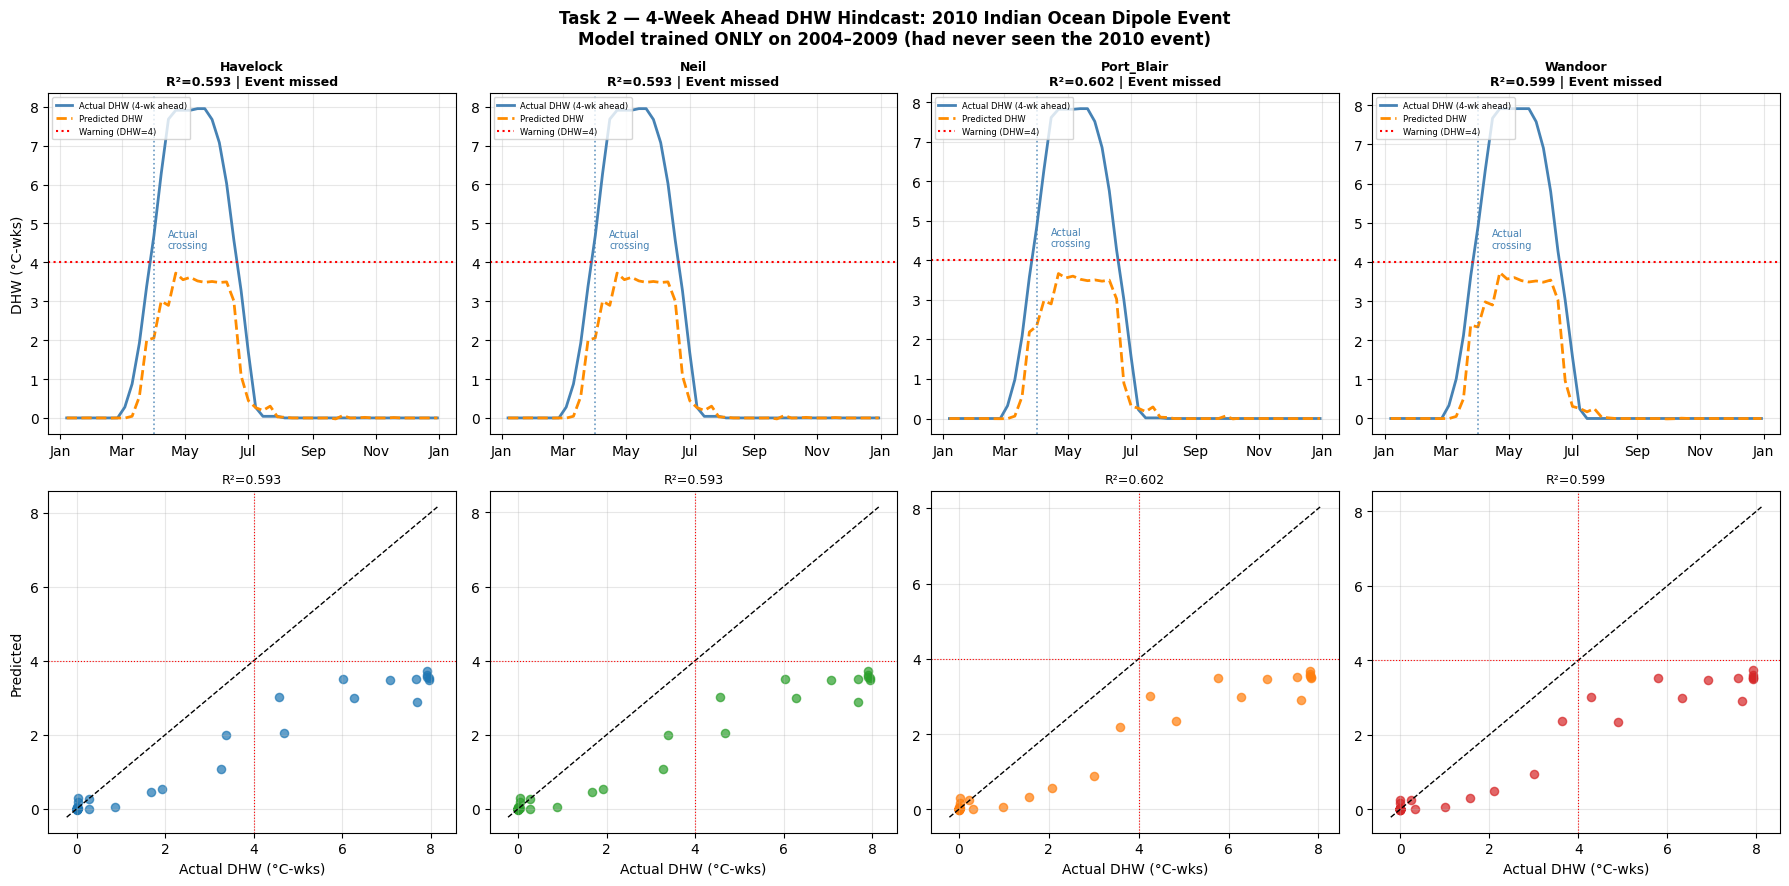

Saved: task2_hindcast_2010.png

2010 Hindcast summary:
  Havelock    : R²=0.593  Lead=Event missed
  Neil        : R²=0.593  Lead=Event missed
  Port_Blair  : R²=0.602  Lead=Event missed
  Wandoor     : R²=0.599  Lead=Event missed


In [20]:
# ── Cell 18 ── Hindcast 2010 — Lead Time Analysis ─────────────────────────
#
# The most important question: By how many WEEKS did the model predict the
# Warning threshold (DHW≥4) BEFORE the actual threshold was crossed?
#
# If predicted_crossing_date < actual_crossing_date → advance warning achieved.
# Lead time = actual_date - predicted_date (positive = model was ahead)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(
    'Task 2 — 4-Week Ahead DHW Hindcast: 2010 Indian Ocean Dipole Event\n'
    'Model trained ONLY on 2004–2009 (had never seen the 2010 event)',
    fontsize=12, fontweight='bold'
)

WARNING_THRESH = 4.0
hindcast_summary = []

for col_idx, site in enumerate(SITES):
    mask = test_2010['label'] == site
    site_dates  = pd.to_datetime(test_2010.loc[mask, 'date'].values)
    actual_dhw  = test_2010.loc[mask, 'DHW_4w_ahead'].values
    pred_dhw    = xgb_dhw.predict(test_2010.loc[mask, FORECAST_FEATS])

    # Threshold crossing dates
    actual_cross = next((d for d, v in zip(site_dates, actual_dhw) if v >= WARNING_THRESH), None)
    pred_cross   = next((d for d, v in zip(site_dates, pred_dhw)   if v >= WARNING_THRESH), None)

    if actual_cross and pred_cross:
        lead_weeks = (actual_cross - pred_cross).days // 7
        lead_str = f'+{lead_weeks} weeks lead' if lead_weeks > 0 else f'{lead_weeks} wks (late)'
    elif pred_cross and not actual_cross:
        lead_str = 'False alarm'
        lead_weeks = None
    elif actual_cross and not pred_cross:
        lead_str = 'Event missed'
        lead_weeks = None
    else:
        lead_str = 'No event'
        lead_weeks = None

    r2_site = r2_score(actual_dhw, pred_dhw)
    hindcast_summary.append({'site': site, 'r2_2010': round(r2_site, 3),
                              'lead_weeks': lead_weeks, 'result': lead_str})

    # Top row: time series
    ax1 = axes[0, col_idx]
    ax1.plot(site_dates, actual_dhw, color='steelblue', lw=2, label='Actual DHW (4-wk ahead)')
    ax1.plot(site_dates, pred_dhw,  color='darkorange', lw=2, linestyle='--', label='Predicted DHW')
    ax1.axhline(WARNING_THRESH, color='red', lw=1.5, linestyle=':', label='Warning (DHW=4)')
    if actual_cross:
        ax1.axvline(actual_cross, color='steelblue', lw=1.2, linestyle=':', alpha=0.8)
        ax1.annotate('Actual\ncrossing', xy=(actual_cross, WARNING_THRESH),
                     xytext=(10, 10), textcoords='offset points', fontsize=7, color='steelblue')
    if pred_cross:
        ax1.axvline(pred_cross, color='darkorange', lw=1.2, linestyle=':', alpha=0.8)
        ax1.annotate('Predicted\ncrossing', xy=(pred_cross, WARNING_THRESH),
                     xytext=(-60, 15), textcoords='offset points', fontsize=7, color='darkorange')
    ax1.set_title(f'{site}\nR²={r2_site:.3f} | {lead_str}', fontsize=9, fontweight='bold')
    ax1.set_ylabel('DHW (°C-wks)' if col_idx == 0 else '')
    ax1.legend(fontsize=6, loc='upper left')
    ax1.grid(alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    # Bottom row: scatter actual vs predicted
    ax2 = axes[1, col_idx]
    ax2.scatter(actual_dhw, pred_dhw, color=SITE_COLORS[site], alpha=0.7, s=35)
    lo = min(actual_dhw.min(), pred_dhw.min()) - 0.2
    hi = max(actual_dhw.max(), pred_dhw.max()) + 0.2
    ax2.plot([lo, hi], [lo, hi], 'k--', lw=1, label='Perfect fit')
    ax2.axvline(WARNING_THRESH, color='red', lw=0.8, ls=':')
    ax2.axhline(WARNING_THRESH, color='red', lw=0.8, ls=':')
    ax2.set_xlabel('Actual DHW (°C-wks)'); ax2.set_ylabel('Predicted' if col_idx == 0 else '')
    ax2.set_title(f'R²={r2_site:.3f}', fontsize=9)
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'task2_hindcast_2010.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task2_hindcast_2010.png')
print()
print('2010 Hindcast summary:')
for row in hindcast_summary:
    print(f"  {row['site']:<12}: R²={row['r2_2010']}  Lead={row['result']}")


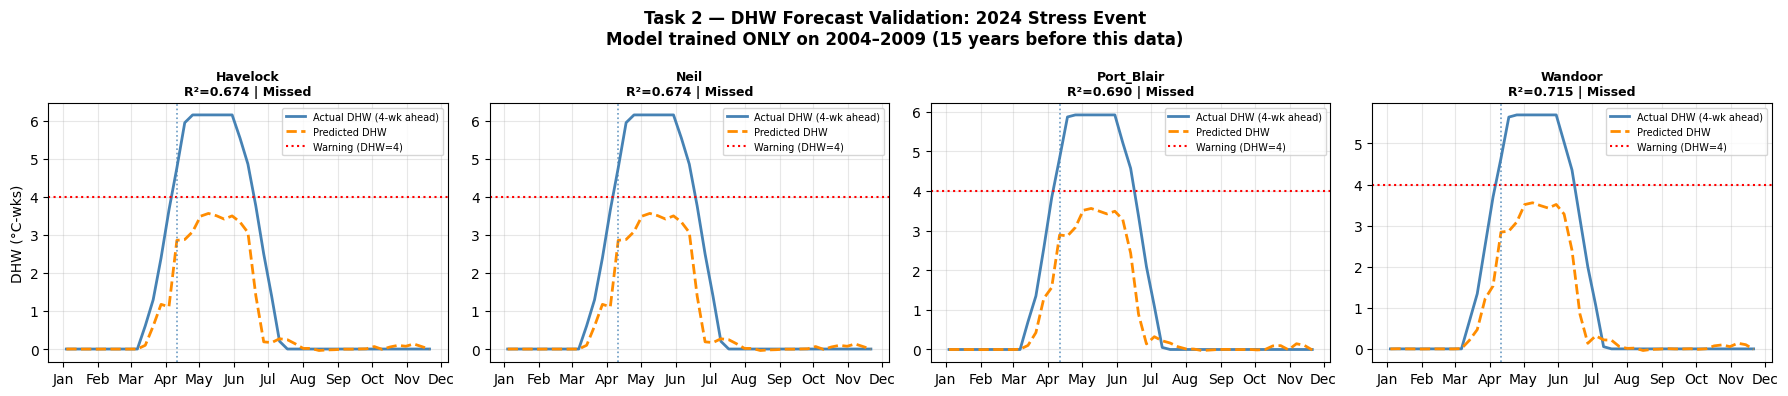

Saved: task2_hindcast_2024.png

HINDCAST PREDICTION SUMMARY
Site          Train R²   2010 R²    2010 Lead   2024 R²    2024 Lead
------------------------------------------------------------
Havelock     (2004-09)     0.593 Event missed     0.674       Missed
Neil         (2004-09)     0.593 Event missed     0.674       Missed
Port_Blair   (2004-09)     0.602 Event missed      0.69       Missed
Wandoor      (2004-09)     0.599 Event missed     0.715       Missed

Saved: task2_hindcast_results.csv


In [21]:
# ── Cell 19 ── Validation on 2024 & Summary ───────────────────────────────
# Does the same model (trained on 2004-2009) also predict the 2024 event?
# This is the strongest test of generalization:
# the model must predict a stress event 15 years outside its training window.

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
fig.suptitle(
    'Task 2 — DHW Forecast Validation: 2024 Stress Event\n'
    'Model trained ONLY on 2004–2009 (15 years before this data)',
    fontsize=12, fontweight='bold'
)

validation_summary = []

for col_idx, site in enumerate(SITES):
    mask = test_2024['label'] == site
    if mask.sum() == 0:
        continue
    site_dates = pd.to_datetime(test_2024.loc[mask, 'date'].values)
    actual     = test_2024.loc[mask, 'DHW_4w_ahead'].values
    pred       = xgb_dhw.predict(test_2024.loc[mask, FORECAST_FEATS])

    actual_cross = next((d for d, v in zip(site_dates, actual) if v >= WARNING_THRESH), None)
    pred_cross   = next((d for d, v in zip(site_dates, pred)   if v >= WARNING_THRESH), None)

    if actual_cross and pred_cross:
        lead_weeks = (actual_cross - pred_cross).days // 7
        lead_str = f'+{lead_weeks}wk lead' if lead_weeks > 0 else f'late {abs(lead_weeks)}wk'
    elif pred_cross and not actual_cross:
        lead_str, lead_weeks = 'False alarm', None
    elif actual_cross and not pred_cross:
        lead_str, lead_weeks = 'Missed', None
    else:
        lead_str, lead_weeks = 'No event (correct)', None

    r2_site = r2_score(actual, pred)
    validation_summary.append({'site': site, 'r2_2024': round(r2_site, 3),
                                'lead_weeks': lead_weeks, 'result': lead_str})

    ax = axes[col_idx]
    ax.plot(site_dates, actual, color='steelblue', lw=2, label='Actual DHW (4-wk ahead)')
    ax.plot(site_dates, pred,   color='darkorange', lw=2, linestyle='--', label='Predicted DHW')
    ax.axhline(WARNING_THRESH, color='red', lw=1.5, linestyle=':', label='Warning (DHW=4)')
    if actual_cross:
        ax.axvline(actual_cross, color='steelblue', lw=1.2, ls=':', alpha=0.8)
    if pred_cross:
        ax.axvline(pred_cross, color='darkorange', lw=1.2, ls=':', alpha=0.8)
    ax.set_title(f'{site}\nR²={r2_site:.3f} | {lead_str}', fontsize=9, fontweight='bold')
    ax.set_ylabel('DHW (°C-wks)' if col_idx == 0 else '')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig(OUT / 'task2_hindcast_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task2_hindcast_2024.png')

# ── Final hindcast summary table ──
print()
print('=' * 60)
print('HINDCAST PREDICTION SUMMARY')
print('=' * 60)
print(f'{"Site":<12} {"Train R²":>9} {"2010 R²":>9} {"2010 Lead":>12} {"2024 R²":>9} {"2024 Lead":>12}')
print('-' * 60)
for h, v in zip(hindcast_summary, validation_summary):
    print(f'{h["site"]:<12} {"(2004-09)":>9} {h["r2_2010"]:>9} {h["result"]:>12} {v["r2_2024"]:>9} {v["result"]:>12}')

# Save combined results
combined = []
for h, v in zip(hindcast_summary, validation_summary):
    combined.append({'site': h['site'], 'r2_2010_hindcast': h['r2_2010'],
                     'lead_weeks_2010': h['lead_weeks'], 'result_2010': h['result'],
                     'r2_2024_validation': v['r2_2024'], 'lead_weeks_2024': v['lead_weeks'],
                     'result_2024': v['result']})
pd.DataFrame(combined).to_csv(OUT / 'task2_hindcast_results.csv', index=False)
print('\nSaved: task2_hindcast_results.csv')
